# Check Bias Tinker et al. 2010 Implementation

In [1]:
import numpy as np
import sys

sys.path.append('/global/common/software/des/jesteves/y3_cluster_cpp/y3_buzzard')

In [2]:
from bias import *

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('poster')

### Check Bias Function

From Tinker et al. 2010 Eqn 6
https://arxiv.org/pdf/1001.3162.pdf

$$
b(\nu)=1-A \frac{\nu^a}{\nu^a+\delta_c^a}+B \nu^b+C \nu^c 
$$

Text(0.5, 0, 'log($\\nu$)')

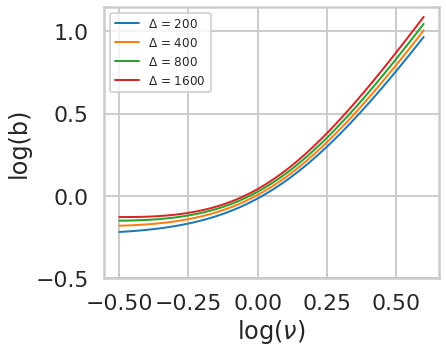

In [4]:
plt.figure(figsize=(6,5))
lnvec = np.linspace(-0.5,0.6,100)
for odelta in [200,400,800,1600]:
    bvec = bias_at_nu(10**lnvec, odelta=odelta)
    plt.plot(lnvec, np.log10(bvec),label=r'$\Delta$ = %i'%odelta, lw=2)
    
plt.ylim(-0.5,1.15)
plt.legend(fontsize=12)
plt.ylabel('log(b)')
plt.xlabel(r'log($\nu$)')

There is a visual agreement with their Figure 2.

In [5]:
def bias_at_nu(nu, odelta=200):
    """ Bias Tinker et a. 2010 Eqn 6
    """
    A, a, B, b, C, c = get_tinker_pars(odelta)
    bias = _bias_at_nu(nu, A, a, B, b, C, c, deltac=1.686)
    return bias

def get_tinker_pars(odelta=200):
    y = np.log10(odelta)
    # for delta=200
    tinker_best_fit = {
        'A': 1.0 + 0.24*y*np.exp(- (4/y)**4),
        'a': 0.44*y - 0.88,
        'B': 0.183,
        'b': 1.5,
        'C': 0.019+0.107*y+0.19*np.exp(-(4/y)**4),
        'c': 2.4
    }
    return [tinker_best_fit[col] for col in ['A','a','B','b','C','c']]

def _bias_at_nu(nu, A, a, B, b, C, c, deltac=1.686):
    """ Bias Tinker et a. 2010 Eqn 6
    """
    res = 1.0 - A * nu**a/ (nu**a + deltac**a)
    res+= B * nu**b
    res+= C* nu**c
    return res


In [6]:
get_tinker_pars(200)

[1.0000597439342158, 0.13245319809215184, 0.183, 1.5, 0.26523076436642345, 2.4]

### Check the Conversion (RL to M)

In [7]:
def convert_m200_to_r200(m200,rho,odelta=200):
    rv = np.power(m200*3.0/(4.0*np.pi*rho*odelta),1.0/3.0)
    return rv

In [8]:
from astropy.constants import G
h = 0.7
omega_m = 0.3

Gv = G.to('Mpc km^2/s^2/Msun').value
rho_c = 3.0*100.0**2/(8.0*np.pi*Gv) # Msun h^2/Mpc^3
rho_m = rho_c*omega_m*h*h

In [9]:
rho_m/33523186529.0007

1.2170049577334625

In [10]:
print(rho_c)

277536627243.6564


In [32]:
def get_block(model,col,dtype=None):
    return np.genfromtxt(root+'%s/%s.txt'%(model.lower(), col),dtype=dtype)

root = '/global/common/software/des/jesteves/y3_cluster_cpp/y1_mock/test/output/'
print(root)

/global/common/software/des/jesteves/y3_cluster_cpp/y1_mock/test/output/


In [33]:
!ls /global/common/software/des/jesteves/y3_cluster_cpp/y1_mock/test/output/growth_parameters


a.txt	d_z.txt   fsigma_8.txt	h.txt	   sigma_8.txt
da.txt	f_ap.txt  f_z.txt	rs_dv.txt  z.txt


In [71]:
deltac = 1.686
znu = get_block('sigma_r','z')
rnu = get_block('sigma_r','r')
nu = deltac/get_block('sigma_r','sigma_r')

mnu = 4.0*np.pi*rho_m*rnu**3/3
np.log10(mnu)[10:70]

array([13.00606216, 13.0464662 , 13.08687024, 13.12727428, 13.16767832,
       13.20808236, 13.2484864 , 13.28889045, 13.32929449, 13.36969853,
       13.41010257, 13.45050661, 13.49091065, 13.53131469, 13.57171873,
       13.61212277, 13.65252681, 13.69293085, 13.73333489, 13.77373893,
       13.81414297, 13.85454701, 13.89495105, 13.93535509, 13.97575913,
       14.01616317, 14.05656721, 14.09697125, 14.13737529, 14.17777933,
       14.21818337, 14.25858742, 14.29899146, 14.3393955 , 14.37979954,
       14.42020358, 14.46060762, 14.50101166, 14.5414157 , 14.58181974,
       14.62222378, 14.66262782, 14.70303186, 14.7434359 , 14.78383994,
       14.82424398, 14.86464802, 14.90505206, 14.9454561 , 14.98586014,
       15.02626418, 15.06666822, 15.10707226, 15.1474763 , 15.18788034,
       15.22828438, 15.26868843, 15.30909247, 15.34949651, 15.38990055])

In [35]:
np.log10(nu[0])

array([0.01382259, 0.01994367, 0.02610862, 0.03232023, 0.03857847,
       0.04488391, 0.05123828, 0.05764114, 0.06409471, 0.0705957 ,
       0.07714693, 0.08374877, 0.09040145, 0.09710724, 0.10386543,
       0.11067869, 0.11754345, 0.1244624 , 0.1314365 , 0.13846556,
       0.14555252, 0.15269635, 0.15990028, 0.16716043, 0.17447929,
       0.18185858, 0.18929757, 0.19679994, 0.20436432, 0.21199444,
       0.21968616, 0.22744146, 0.23526297, 0.24314911, 0.25110429,
       0.25912651, 0.26721991, 0.27537987, 0.28360736, 0.29190593,
       0.30027274, 0.30871284, 0.31722342, 0.3258089 , 0.33446437,
       0.34318952, 0.35198954, 0.36086055, 0.36980901, 0.37883211,
       0.38793554, 0.39711527, 0.40637027, 0.41570873, 0.42512606,
       0.4346306 , 0.44421925, 0.45389801, 0.46366255, 0.47350831,
       0.48344468, 0.49346349, 0.50357289, 0.51376817, 0.52405524,
       0.53443107, 0.54488919, 0.55544457, 0.56608904, 0.57683431,
       0.58767627, 0.59862054, 0.60966388, 0.62079264, 0.63202

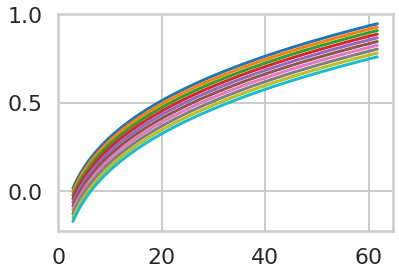

In [36]:
# plt.loglog()

plt.plot(rnu, np.log10(nu[::5].T))

In [37]:
massvec = np.logspace(13,16,20)
rvec = convert_m200_to_r200(massvec, rho_m, odelta=1)

In [82]:
from scipy.interpolate import interp1d
def compute_bias_camb(rnu, znu, nu, massvec, zvec, rhocz, omega_m=0.3):
    Bias = np.zeros((massvec.size, zvec.size))
    for i,z in enumerate(zvec):
        # slice nu(radii,z)
        iz = np.interp(z,znu,np.arange(znu.size)).astype(int)
        nui = nu[iz]

        # convert mass to r200
        rhom = rhocz[i]*omega_m
        rvec = convert_m200_to_r200(massvec, rhom, odelta=1)
        
        # interpolate with the new radii vector
        _nui = np.exp(interp1d(rnu, np.log(nui), fill_value='extrapolate')(rvec))
        Bias[:,i] = bias_at_nu(_nui, odelta=200)
    return Bias


In [83]:
zvec = get_block('distances','z') 
hz = h*np.sqrt( omega_m*(1+zvec)**3 + (1-omega_m))
rhocz = rho_c * hz**2

In [84]:
bias2d = compute_bias_camb(rnu, znu, nu, massvec, zvec, rhocz*omega_m)
bias2d[:,12]

array([ 0.86367116,  0.90942176,  0.96408531,  1.02974807,  1.10907122,
        1.20542596,  1.32314112,  1.46771499,  1.64648151,  1.86910188,
        2.14866347,  2.50205632,  2.9520663 ,  3.52998591,  4.27834173,
        5.25592819,  6.54454684,  8.25937089, 10.56304824, 13.68899775])

In [85]:
massvec

array([1.00000000e+13, 1.43844989e+13, 2.06913808e+13, 2.97635144e+13,
       4.28133240e+13, 6.15848211e+13, 8.85866790e+13, 1.27427499e+14,
       1.83298071e+14, 2.63665090e+14, 3.79269019e+14, 5.45559478e+14,
       7.84759970e+14, 1.12883789e+15, 1.62377674e+15, 2.33572147e+15,
       3.35981829e+15, 4.83293024e+15, 6.95192796e+15, 1.00000000e+16])

In [79]:
# np.log(nu[0])

In [65]:
z = 0.3
i = 10
iz = np.interp(z,znu,np.arange(znu.size)).astype(int)
nui = nu[iz]

# convert mass to r200
rhom = rhocz[i]*omega_m
rvec = convert_m200_to_r200(massvec, rhom, odelta=1)
print(rvec)
# interpolate with the new radii vector
_nui = interp1d(rnu,nui)(rvec)

[ 3.62965494  4.09729202  4.62517849  5.22107674  5.89374926  6.65308748
  7.51025725  8.47786296  9.57013295 10.8031287  12.19498103 13.76615667
 15.53975927 17.54186909 19.80192652 22.35316499 25.23309964 28.484079
 32.15390768 36.29654936]


In [42]:
# np.arange(rmin,rmax

In [43]:
rmin,rmax = 1.,40.
nr = 10
rbins = np.linspace(np.power(rmin,1/3.),np.power(rmax,1/3.),nr)**3
rbins

array([ 1.        ,  2.04298555,  3.6364003 ,  5.89688328,  8.94107352,
       12.88561007, 17.84713196, 23.94227822, 31.28768789, 40.        ])

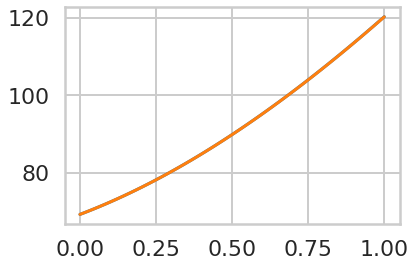

In [44]:
from astropy.cosmology import WMAP9 as cosmo
plt.plot(zvec,cosmo.H(zvec).value)
plt.plot(zvec,cosmo.H(0).value*np.sqrt(cosmo.Om0*(1+zvec)**3+(1-cosmo.Om0)))

In [45]:
rho_m/71615338390.43785

0.5696808131016924